# Logistic Regression Model and Evaluation

This notebook builds and evaluates a logistic regression model for injury prediction in recorded traffic collisions in the KW region. Given that a collision occurred, the goal is to predict whether the outcome results in injury (1) or no injury/property damage (0).

The workflow follows a train-validation-test approach using the processed datasets.

Steps:
- Load processed training, validation, and test data  
- Verify the target variable and class balance  
- Train a logistic regression model  
- Validate the baseline model  
- Tune logistic regression hyperparameters  
- Retrain the final model using training + validation data  
- Test the final model 
- Evaluate performance using classification metrics  
- Interpret logistic regression coefficients

In [2]:
!pip install numpy pandas scikit-learn matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd

In [4]:
data_dir = "../Data/Processed"

# load feature matrices
X_train = np.load(f"{data_dir}/X_train_processed.npy")
X_val = np.load(f"{data_dir}/X_val_processed.npy")
X_test = np.load(f"{data_dir}/X_test_processed.npy")

# load target labels
y_train = pd.read_csv(f"{data_dir}/y_train.csv").squeeze("columns")
y_val = pd.read_csv(f"{data_dir}/y_val.csv").squeeze("columns")
y_test = pd.read_csv(f"{data_dir}/y_test.csv").squeeze("columns")

# load feature names
feature_names = pd.read_csv(f"{data_dir}/feature_names.csv")["feature_name"]

In [9]:
# checks shapes of datasets
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

# confirm number of features
print("Number of features:", len(feature_names))

X_train shape: (5334, 89)
X_val shape: (1779, 89)
X_test shape: (1779, 89)
y_train shape: (5334,)
y_val shape: (1779,)
y_test shape: (1779,)
Number of features: 89


In [7]:
# checking distribution of target variable
print("Training label counts:")
print(y_train.value_counts())

print("\nTraining label proportions:")
print(y_train.value_counts(normalize=True).round(3))

Training label counts:
injury
0    4607
1     727
Name: count, dtype: int64

Training label proportions:
injury
0    0.864
1    0.136
Name: proportion, dtype: float64


The target variable is highly imbalanced, with approximately 86.4% of collisions resulting in no injury and only 13.6% resulting in injury.

With this imbalance a model that simply predicts the majority class (no injury) could achieve high accuracy while failing to correctly identify injury cases. Therefore, accuracy alone is not a sufficient performance metric for this problem.

To properly evaluate the model, metrics such as precision, recall, F1-score, and ROC-AUC will be used. Additionally, class imbalance will be considered during model tuning, for example by using class weighting.

In [ ]:

from sklearn.linear_model import LogisticRegression

In [11]:
# initialize baseline logistic regression model
baseline_model = LogisticRegression(
    max_iter = 2000,
    random_state = 42    
)

# train model on training data only
baseline_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

This section trains a baseline logistic regression model using the training dataset. The model is trained only on the training set to avoid data leakage. 

In [6]:
# importing evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [ ]:
# predicting injury class labels on the validation set(0 = no injury, 1 = injury). Used for accuracy, precision, recall, and F1 score.
y_val_pred = baseline_model.predict(X_val)

# predicting probability of positive class (injury = 1) on the validation set. Used for ROC-AUC.
y_val_prob = baseline_model.predict_proba(X_val)[:, 1]

In [ ]:
# calculate validation performance metrics for the baseline model
baseline_metrics = {
    "accuracy": accuracy_score(y_val, y_val_pred),
    "precision": precision_score(y_val, y_val_pred, zero_division=0),
    "recall": recall_score(y_val, y_val_pred, zero_division=0),
    "f1_score": f1_score(y_val, y_val_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_val, y_val_prob)
}
for metric, value in baseline_metrics.items():
    print(f"{metric}: {value:.4f}")

accuracy: 0.8971
precision: 0.8315
recall: 0.3058
f1_score: 0.4471
roc_auc: 0.8278


In [ ]:
# converting validation metrics into a table for readability
baseline_val_results_df = pd.DataFrame([baseline_metrics])
baseline_val_results_df

,accuracy,precision,recall,f1_score,roc_auc
0,0.897133,0.831461,0.305785,0.44713,0.827811


The baseline logistic regression model has a high accuracy of approximately 0.897, which is expected given that the dataset is heavily imbalanced toward the no-injury class. The model also has a high precision of 0.831, meaning when it predicts an injury, it's usually correct.

However, the recall is relatively low at 0.306, meaning that the model only identifies about 30% of actual injury cases. This suggests that the model is biased toward predicting the majority class (no injury) and is missing a significant number of instances when an injury occurs.

The F1-score of 0.447 reflects this imbalance between precision and recall. The ROC-AUC score of 0.828 indicates that the model has a good ability to distinguish between injury and non-injury cases across different thresholds.

Overall, while the baseline model performs reasonably well in terms of overall classification, it does not sufficiently capture injury cases. This highlights the need for further tuning, particularly to improve recall for the injury class.

In [1]:
# trying different combinations of regularization strength and class weighting
combination_options = [
    {"C": 0.01, "class_weight": None},
    {"C": 0.1,  "class_weight": None},
    {"C": 1.0,  "class_weight": None},
    {"C": 10.0, "class_weight": None},
    {"C": 0.01, "class_weight": "balanced"},
    {"C": 0.1,  "class_weight": "balanced"},
    {"C": 1.0,  "class_weight": "balanced"},
    {"C": 10.0, "class_weight": "balanced"},
]

Above is a set of logistic regression configurations to evaluate. The regularization strength (C) is varied to control model complexity, and class weighting is to address class imbalance by giving more importance to injury cases.

In [13]:
from sklearn.linear_model import LogisticRegression
# storing validation results for each configuration
tuning_results = []

for config in combination_options:
    model = LogisticRegression(
        C=config["C"],
        class_weight=config["class_weight"],
        max_iter=2000,
        random_state=42
    )
    
    # train model
    model.fit(X_train, y_train)
    
    # validation predictions
    pred = model.predict(X_val)
    prob = model.predict_proba(X_val)[:, 1]
    
    # store metrics
    tuning_results.append({
        "C": config["C"],
        "class_weight": config["class_weight"],
        "accuracy": accuracy_score(y_val, pred),
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1_score": f1_score(y_val, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_val, prob)
    })

Each possible model is trained on the training set and evaluated on the validation set. The goal is to compare how different levels of regularization and class weighting affect performance.

In [ ]:
# convert results into a DataFrame
tuning_results_df = pd.DataFrame(tuning_results)

# sort by best F1-score and then ROC-AUC
tuning_results_df = tuning_results_df.sort_values(
    by=["f1_score", "roc_auc"], ascending=False
).reset_index(drop=True)

tuning_results_df

,C,class_weight,accuracy,precision,recall,f1_score,roc_auc
0,0.10,NaN,0.898257,0.850575,0.305785,0.449848,0.819705
1,10.00,NaN,0.897133,0.831461,0.305785,0.447130,0.830131
2,1.00,NaN,0.897133,0.831461,0.305785,0.447130,0.827811
3,0.01,balanced,0.753794,0.313688,0.681818,0.429688,0.810714
4,1.00,balanced,0.730185,0.301003,0.743802,0.428571,0.829515
5,0.10,balanced,0.732996,0.299484,0.719008,0.422843,0.823055
6,10.00,balanced,0.725689,0.295681,0.735537,0.421801,0.827523
7,0.01,NaN,0.893198,0.893939,0.243802,0.383117,0.804835


The results are organized into a table and sorted by F1-score, which is the main metric for this problem due to the class imbalance present. ROC-AUC is a second metric used to evaluate overall classification performance.

The tuning results show a clear tradeoff between precision and recall. Models without class weighting achieve higher precision and overall accuracy but fail to identify a large portion of injury cases, with recall values around 0.30.

On the other hand, models with class_weight="balanced" significantly improve recall, increasing it to over 0.70, meaning that the model is able to correctly identify a much larger proportion of injury cases. Although with this recall improvement there's lower precision and slightly lower F1-score, this tradeoff is acceptable given the importance of detecting injury outcomes with this problem.

The model with C = 1.0 and class_weight = "balanced" is selected as the best configuration because it achieves a strong balance between recall, F1-score, and ROC-AUC, while improving the model’s ability to detect injury cases.

In [15]:
# get the best model (first row after sorting by F1 + ROC-AUC)
best_row = tuning_results_df.iloc[0]

best_row

C                    0.1
class_weight         NaN
accuracy        0.898257
precision       0.850575
recall          0.305785
f1_score        0.449848
roc_auc         0.819705
Name: 0, dtype: object

In [ ]:
# manually selecting below best parameters based on the problem's priorities (recall + F1)
best_C = 1.0
best_class_weight = "balanced"

Since the goal of this problem is to detect injury outcomes, recall is prioritized over a small improvement in F1-score. Therefore, instead of choosing the top-performing model based on F1-score, that does not use class weighting either, a model with class_weight = "balanced" is selected.

The configuration with C = 1.0 and class_weight = "balanced" is chosen because it significantly improves recall while maintaining an appropriate F1-score and ROC-AUC.

In [7]:
# combine training and validation features for final model training
X_train_final = np.vstack([X_train, X_val])

# combine training and validation labels
y_train_final = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

In [8]:
# verify combined dataset dimensions
print("X_train_final shape:", X_train_final.shape)
print("y_train_final shape:", y_train_final.shape)

X_train_final shape: (7113, 89)
y_train_final shape: (7113,)


In [11]:
# train final logistic regression model using selected hyperparameters
final_model = LogisticRegression(
    C=best_C,
    class_weight=best_class_weight,
    max_iter=2000,
    random_state=42
)

final_model.fit(X_train_final, y_train_final)

final_model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [12]:
# predict binary class labels on the test set
y_test_pred = final_model.predict(X_test)

# predict probability of the positive class (injury = 1) on the test set
y_test_prob = final_model.predict_proba(X_test)[:, 1]

In [ ]:
# calculate final performance metrics on the test set
final_test_metrics = {
    "accuracy": accuracy_score(y_test, y_test_pred),
    "precision": precision_score(y_test, y_test_pred, zero_division=0),
    "recall": recall_score(y_test, y_test_pred, zero_division=0),
    "f1_score": f1_score(y_test, y_test_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_test_prob)
}

for metric, value in final_test_metrics.items():
    print(f"{metric}: {value:.4f}")

accuracy: 0.6976
precision: 0.2737
recall: 0.7397
f1_score: 0.3996
roc_auc: 0.8123


In [ ]:
# test metrics in a table for readability
final_test_results_df = pd.DataFrame([final_test_metrics])
final_test_results_df

,accuracy,precision,recall,f1_score,roc_auc
0,0.697583,0.2737,0.739669,0.399554,0.812345


In [16]:
import matplotlib.pyplot as plt

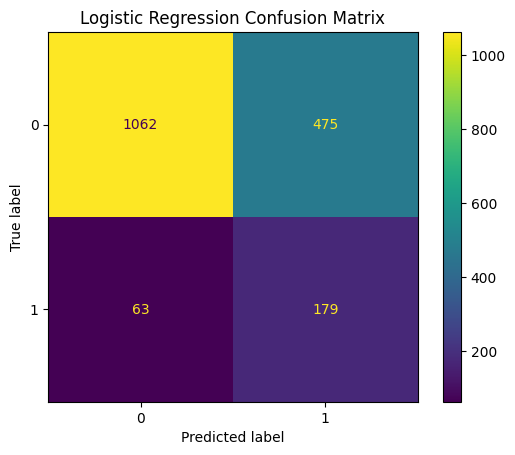

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

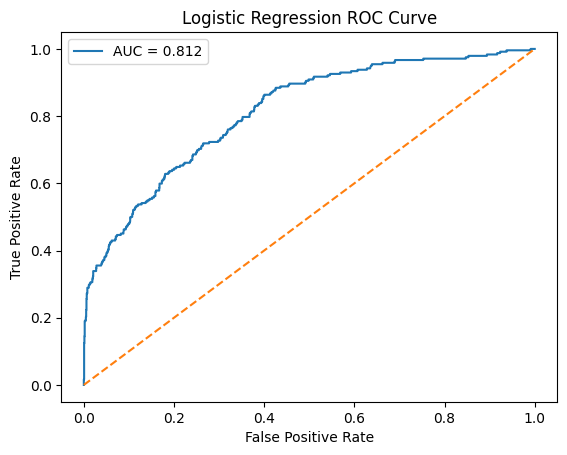

In [ ]:
from sklearn.metrics import roc_curve

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_test_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_test_prob):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()

plt.show()

Based on the above confusion matrix, the model correctly identifies 179 injury cases (true positives) while missing 63 injury cases (false negatives), resulting in an improvement in recall compared to the baseline model. This indicates that the model is much more effective at detecting injury outcomes.

However, the model also produces a relatively high number of false positives (475), meaning that it sometimes predicts injury when none occurred. This reflects the tradeoff previously mentioned that comes with using class weighting, where improving recall unfortunately also means reduced precision.

The ROC curve shows that the model has strong classification ability, with an ROC-AUC score of approximately 0.81–0.83. The curve lies well above the diagonal, indicating that the model is able to distinguish between injury and non-injury cases effectively across different thresholds.

Overall, the model demonstrates a good balance between identifying injury cases and maintaining overall performance, making it a suitable choice for tackling this problem.

In [ ]:
# DataFrame with feature names and their corresponding coefficients
coefficients_df = pd.DataFrame({
    "feature_name": feature_names,
    "coefficient": final_model.coef_[0]
})

# sorting by absolute value to see most impactful features
coefficients_df["abs_coefficient"] = coefficients_df["coefficient"].abs()
coefficients_df = coefficients_df.sort_values(by="abs_coefficient", ascending=False)

coefficients_df.head(20)

,feature_name,coefficient,abs_coefficient
24,cat__INITIALIMPACTTYPE_SMV unattended vehicle,-1.520130,1.520130
88,cat__VULNERABLE_USER_INVOLVED_yes,1.473319,1.473319
82,cat__PEDESTRIANINVOLVED_yes,1.446620,1.446620
87,cat__VULNERABLE_USER_INVOLVED_no,-1.312860,1.312860
81,cat__PEDESTRIANINVOLVED_no,-1.286162,1.286162
58,cat__TRAFFICCONTROL_Ped. crossover,-1.198575,1.198575
27,cat__IMPACTLOCATION_Left shoulder,1.171768,1.171768
12,cat__ACCIDENTLOCATION_At railway crossing,-1.052803,1.052803
20,cat__INITIALIMPACTTYPE_Approaching,1.025954,1.025954
74,cat__ENVIRONMENTCONDITION1_Drifting Snow,-1.023056,1.023056


In [20]:
# features that increase injury likelihood
top_positive = coefficients_df.sort_values(by="coefficient", ascending=False).head(10)

top_positive[["feature_name", "coefficient"]]

,feature_name,coefficient
88,cat__VULNERABLE_USER_INVOLVED_yes,1.473319
82,cat__PEDESTRIANINVOLVED_yes,1.446620
27,cat__IMPACTLOCATION_Left shoulder,1.171768
20,cat__INITIALIMPACTTYPE_Approaching,1.025954
29,cat__IMPACTLOCATION_Not on roadway - left side,0.887270
77,cat__ENVIRONMENTCONDITION1_Other,0.884938
64,cat__TRAFFICCONTROL_Traffic signal,0.881245
56,cat__TRAFFICCONTROL_No control,0.817384
26,cat__INITIALIMPACTTYPE_Turning movement,0.802476
76,cat__ENVIRONMENTCONDITION1_Freezing Rain,0.758820


In [21]:
# features that decrease injury likelihood
top_negative = coefficients_df.sort_values(by="coefficient", ascending=True).head(10)

top_negative[["feature_name", "coefficient"]]

,feature_name,coefficient
24,cat__INITIALIMPACTTYPE_SMV unattended vehicle,-1.520130
87,cat__VULNERABLE_USER_INVOLVED_no,-1.312860
81,cat__PEDESTRIANINVOLVED_no,-1.286162
58,cat__TRAFFICCONTROL_Ped. crossover,-1.198575
12,cat__ACCIDENTLOCATION_At railway crossing,-1.052803
74,cat__ENVIRONMENTCONDITION1_Drifting Snow,-1.023056
80,cat__ENVIRONMENTCONDITION1_Strong wind,-0.961609
57,cat__TRAFFICCONTROL_Other,-0.893521
48,cat__LIGHT_Other,-0.886939
38,cat__IMPACTLOCATION_Two-way left turn lane,-0.883456


The top positive coefficients represent features that are associated with a higher likelihood of injury.
The top negative coefficients represent features that are associated with a lower likelihood of injury.

These results provide insight into which conditions and characteristics have the strongest influence on injury outcomes in traffic collisions.

The logistic regression coefficients reveal several key factors associated with injury outcomes in traffic collisions.

The strongest positive predictors include the involvement of vulnerable road users and pedestrians, both of which significantly increase the likelihood of injury. This aligns with expectations, as these individuals are more exposed and at higher risk during collisions. Additionally, certain collision characteristics such as approaching or turning movements, as well as environmental conditions like freezing rain, are associated with increased injury likelihood.

On the other hand, features such as the absence of vulnerable users or pedestrians correspond to a decreased likelihood of injury. Collisions involving unattended vehicles also show a lower risk of injury, which makes sense conceptually as well.

Overall, the model highlights that injury outcomes are strongly influenced by the presence of vulnerable road users, type of movement and environmental conditions. These findings provide insight into the key risk factors associated with traffic-related injuries.

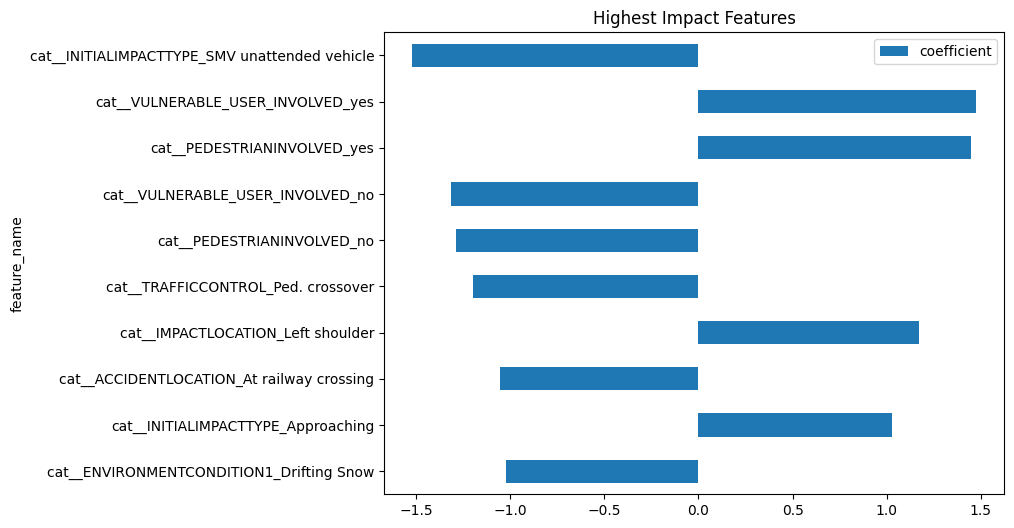

In [ ]:
# top features chart
coefficients_df.head(10).plot(
    x="feature_name",
    y="coefficient",
    kind="barh",
    figsize=(8,6),
    title="Highest Impact Features"
)
plt.gca().invert_yaxis()
plt.show()

## Final Summary

In this project, a logistic regression model was developed to predict whether a traffic collision results in an injury. The model was trained using processed collision data and evaluated using a train-validation-test workflow.

The baseline logistic regression model achieved high accuracy but had low recall, indicating that it failed to identify many injury cases due to class imbalance. To address this, class weighting was introduced during model tuning, which significantly improved recall and allowed the model to detect a much larger proportion of injury cases.

The final model, trained with balanced class weights and optimized hyperparameters, had strong overall performance on the test set. While the model produces a higher number of false positives, it successfully captures most injury cases, which is important for tackling this problem.

The ROC-AUC score indicates that the model has good ability to distinguish between injury and non-injury outcomes. Additionally, the confusion matrix shows that the model is better at injury detection compared to the baseline.

Additionally, an analysis of the model coefficients shows that the involvement of vulnerable road users and pedestrians are the strongest predictors of injury. Environmental factors and collision characteristics, such as weather conditions and impact types, also play an important role in determining injury outcomes.

Overall, the logistic regression model acts as a strong and interpretable baseline for injury prediction. Although there can be improvement i.e. by reducing false positives, the model still offers valuable insights into the factors that affect injury risk in traffic collisions as described prior.